In [1]:
import pandas as pd

/tmp/ipykernel_1642462/4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [5]:
hapfm = pd.read_csv('../../grenenet_reads/average_seedmix_p0.txt',sep = '\t', header=None)

In [37]:
hapfm.columns = ['chrom', 'pos', 'freq_hapfm']

In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path("/home/tbellagio/scratch/pang/test_freqk/seedmix")
K = "k31"
SAMPLES = [f"S{i}" for i in range(1, 9)]

rows = []

for s in SAMPLES:
    print(s)
    work = BASE / "results" / s / K

    # --- index (chrom/pos) ---
    idx_path = work / f"{s}.k31.freqk.ref_index"
    idx = pd.read_csv(idx_path, header=None)[[1,2]]

    idx.columns = ["chrom", "pos"]
    idx["chrom"] = idx["chrom"].astype(str)
    idx["pos"] = idx["pos"].astype(int) + 2   # keep your +2 correction

    # --- freqk allele frequencies ---
    af_path = work / f"{s}.allele_frequencies.k31.dedup.tsv"
    af = pd.read_csv(
        af_path,
        sep=r"|",
        header=None,
        names=["ref_freq", "alt_freq"],
        dtype=str,

    )

    # combine by row order
    one = pd.concat([idx.reset_index(drop=True),
                     af],
                    axis=1)

    one["sample"] = s
    rows.append(one)

# long table: one row per (variant_row, sample)
long = pd.concat(rows, ignore_index=True)

# mean alt freq across samples per position
mean_alt = (
    long.groupby(["chrom", "pos"], as_index=False)
        .agg(
            alt_freq_mean=("alt_freq", "mean"),
            alt_freq_sd=("alt_freq", "std"),
            n_samples=("alt_freq", lambda x: x.notna().sum())
        )
)

long.head(), mean_alt.head()


S1
S2
S3


In [ ]:
out

In [46]:
final = hapfm.merge(freqk, on =['chrom', 'pos'])

In [47]:
final

,chrom,pos,freq_hapfm,ref_freq,freq_freqk
0,1,291,0.037575,1,0
1,1,346,0.264121,0.6666667,0.33333334
2,1,363,0.087739,0.9188192,0.08118081
3,1,434,0.003561,1,0
4,1,465,0.050570,0.8660714,0.13392857
...,...,...,...,...,...
1768422,5,26975121,0.076191,0.9447236,0.05527638
1768423,5,26975148,0.076191,0.9514563,0.048543688
1768424,5,26975215,0.016091,1,0
1768425,5,26975267,0.004589,1,0


OVERALL: n=1,748,453  corr=0.9192  R^2=0.8449


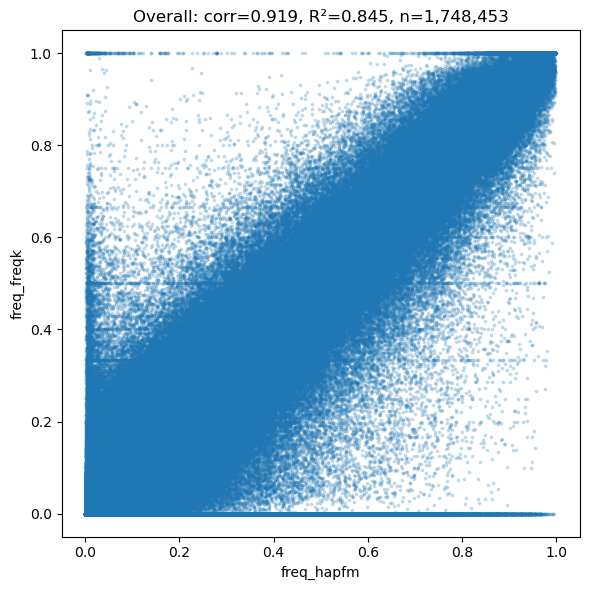

Chr 1: n=457,762  corr=0.9197  R^2=0.8459


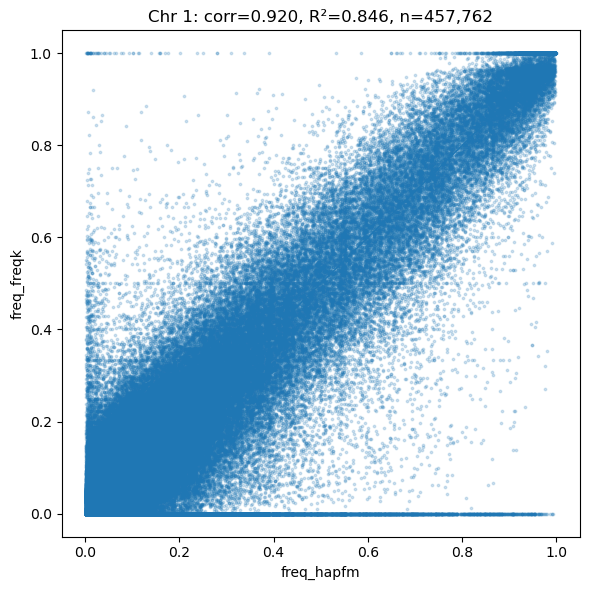

Chr 2: n=281,480  corr=0.9214  R^2=0.8490


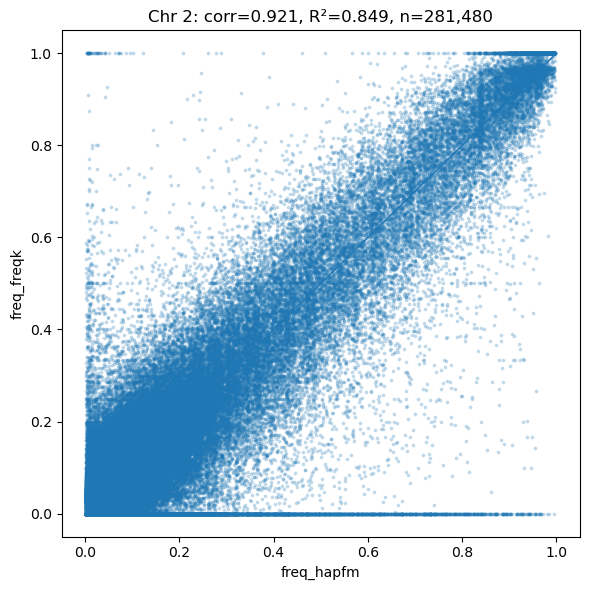

Chr 3: n=327,354  corr=0.9214  R^2=0.8490


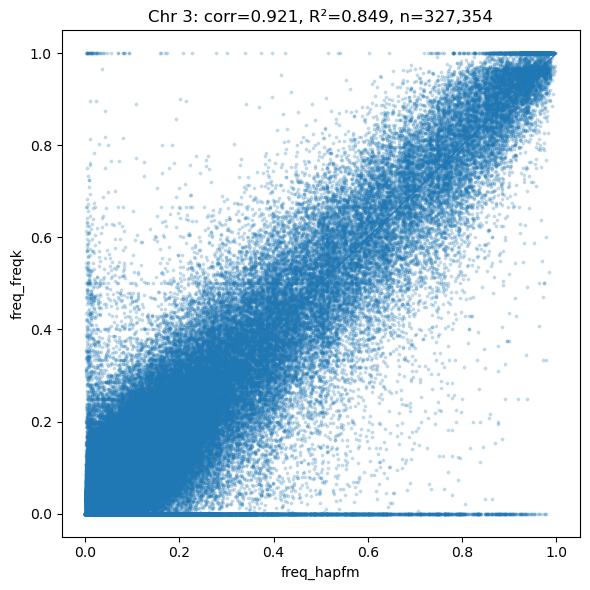

Chr 4: n=276,907  corr=0.9132  R^2=0.8340


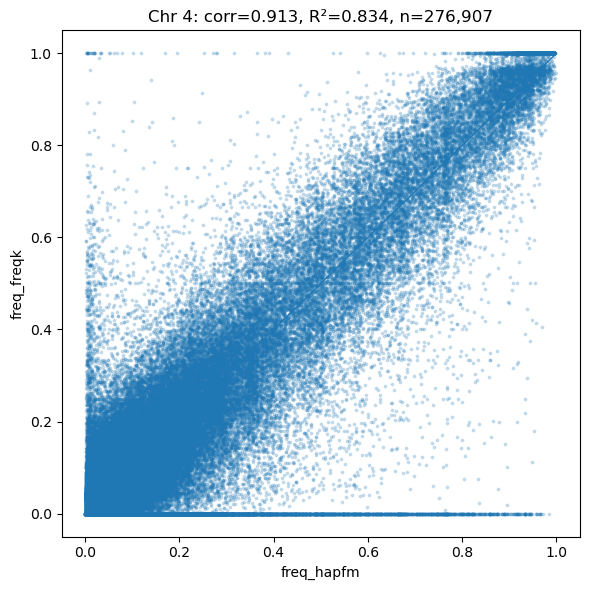

Chr 5: n=404,950  corr=0.9193  R^2=0.8451


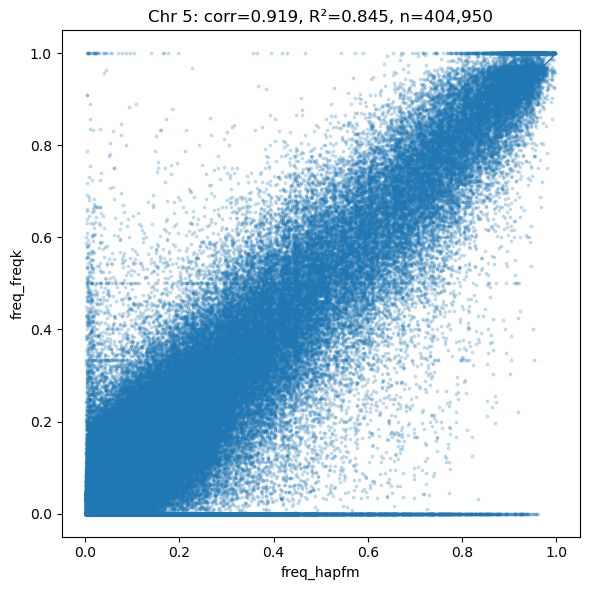

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = final.copy()
df["chrom"] = df["chrom"].astype(str)
xcol, ycol = "freq_hapfm", "freq_freqk"
df[xcol] = pd.to_numeric(df[xcol], errors="coerce")
df[ycol] = pd.to_numeric(df[ycol], errors="coerce")
df = df.dropna(subset=[xcol, ycol])

def corr_r2(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if len(x) < 2:
        return np.nan, np.nan
    r = np.corrcoef(x, y)[0, 1]
    return r, r**2

# ---- overall ----
r_all, r2_all = corr_r2(df[xcol], df[ycol])
print(f"OVERALL: n={len(df):,}  corr={r_all:.4f}  R^2={r2_all:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(df[xcol], df[ycol], s=3, alpha=0.2)
plt.plot([0, 1], [0, 1], linewidth=1)
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"Overall: corr={r_all:.3f}, R²={r2_all:.3f}, n={len(df):,}")
plt.tight_layout()
plt.show()

# ---- per chromosome ----
# sort chroms nicely if they are numeric
chroms = sorted(df["chrom"].unique(), key=lambda c: int(c) if c.isdigit() else c)

for c in chroms:
    g = df[df["chrom"] == c]
    r, r2 = corr_r2(g[xcol], g[ycol])
    print(f"Chr {c}: n={len(g):,}  corr={r:.4f}  R^2={r2:.4f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(g[xcol], g[ycol], s=3, alpha=0.2)
    plt.plot([0, 1], [0, 1], linewidth=1)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"Chr {c}: corr={r:.3f}, R²={r2:.3f}, n={len(g):,}")
    plt.tight_layout()
    plt.show()


In [18]:
#pd.read_csv('results/S1/k31/S1.k31.freqk.var_index', header=None)